# Task 3 (Level 2) — Fraud Detection
### OIBSIP Data Analytics Internship

**Objective:** Build a machine learning pipeline that detects fraudulent card transactions from a heavily imbalanced dataset, treating class imbalance as the core challenge.

**Dataset:** [Credit Card Fraud Detection (ULB Machine Learning Group, Kaggle)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) — 284,807 European card transactions over two days. `V1`–`V28` are anonymised PCA components, plus `Time`, `Amount` and the label `Class` (1 = fraud). Download `creditcard.csv` from Kaggle and place it next to this notebook (it is not committed to the repo because of its size).

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             roc_curve, precision_recall_curve, classification_report)
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
RANDOM_STATE = 42


## 1. Load Data and Check Class Imbalance

In [2]:
df = pd.read_csv("creditcard.csv")
print("Shape:", df.shape)
print("Null values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())


Shape: (284807, 31)
Null values: 0


Duplicate rows: 1081


Duplicate rows are removed **before** splitting so the same transaction can't land in both train and test (that would inflate the scores).

Shape after removing duplicates: (283726, 31)
             count  percent
Class                      
Legitimate  283253   99.833
Fraud          473    0.167


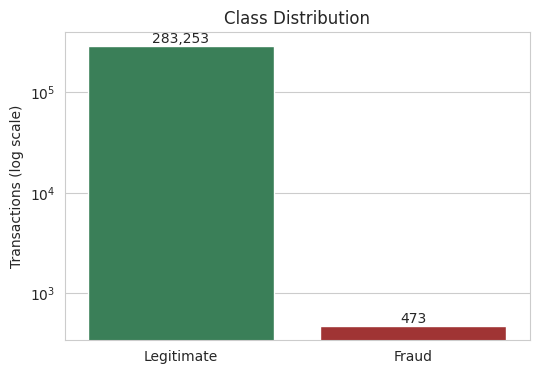

In [3]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

counts = df['Class'].value_counts()
pct = df['Class'].value_counts(normalize=True) * 100
print(pd.DataFrame({'count': counts, 'percent': pct.round(3)}).rename(index={0: 'Legitimate', 1: 'Fraud'}))

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=['Legitimate', 'Fraud'], y=counts.values, hue=['Legitimate', 'Fraud'], palette=['seagreen', 'firebrick'], legend=False)
ax.set_yscale('log')
ax.set_ylabel("Transactions (log scale)")
ax.set_title("Class Distribution")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha='center', va='bottom')
plt.savefig("screenshots/01_class_distribution.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** After removing 1,081 duplicate rows (19 of them fraud), the dataset has 283,726 transactions of which only **473 (0.167%)** are fraud, roughly 1 in 600. This extreme imbalance is the central challenge: a model can ignore the minority class and still look excellent on most metrics.

## 2. Exploratory Data Analysis

### 2.1 Transaction amount: fraud vs. non-fraud

               count    mean     std  min   25%    50%     75%       max
Class                                                                   
Legitimate  283253.0   88.41  250.38  0.0  5.67  22.00   77.46  25691.16
Fraud          473.0  123.87  260.21  0.0  1.00   9.82  105.89   2125.87


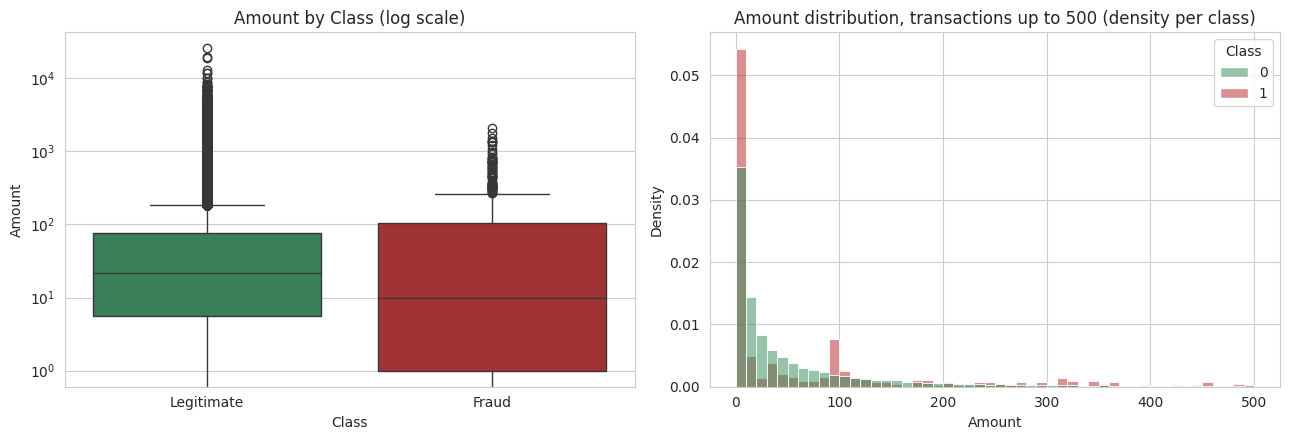

In [4]:
print(df.groupby('Class')['Amount'].describe().rename(index={0: 'Legitimate', 1: 'Fraud'}).round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df, x='Class', y='Amount', hue='Class', palette=['seagreen', 'firebrick'], legend=False, ax=axes[0])
axes[0].set_yscale('log'); axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['Legitimate', 'Fraud'])
axes[0].set_title("Amount by Class (log scale)")
sns.histplot(data=df[df['Amount'] <= 500], x='Amount', hue='Class', bins=50, stat='density', common_norm=False,
             palette=['seagreen', 'firebrick'], ax=axes[1])
axes[1].set_title("Amount distribution, transactions up to 500 (density per class)")
plt.tight_layout()
plt.savefig("screenshots/02_amount_by_class.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** Fraud transactions are not simply bigger. The *median* fraud amount ($9.82) is lower than the median legitimate amount ($22.00), and a quarter of frauds are $1 or less, which fits the pattern of fraudsters testing a stolen card with tiny purchases. But the fraud *mean* ($123.87) is higher than the legitimate mean ($88.41), so there is also a tail of large fraudulent charges. Amount alone cannot separate the classes; the two distributions overlap heavily.

### 2.2 Time-of-day analysis

`Time` is seconds elapsed since the first transaction in the dataset (two days of data). Converting it to an hour of day gives a *relative* time of day: hour 0 is the start of the data, which may not be exactly midnight. The pattern is still informative.

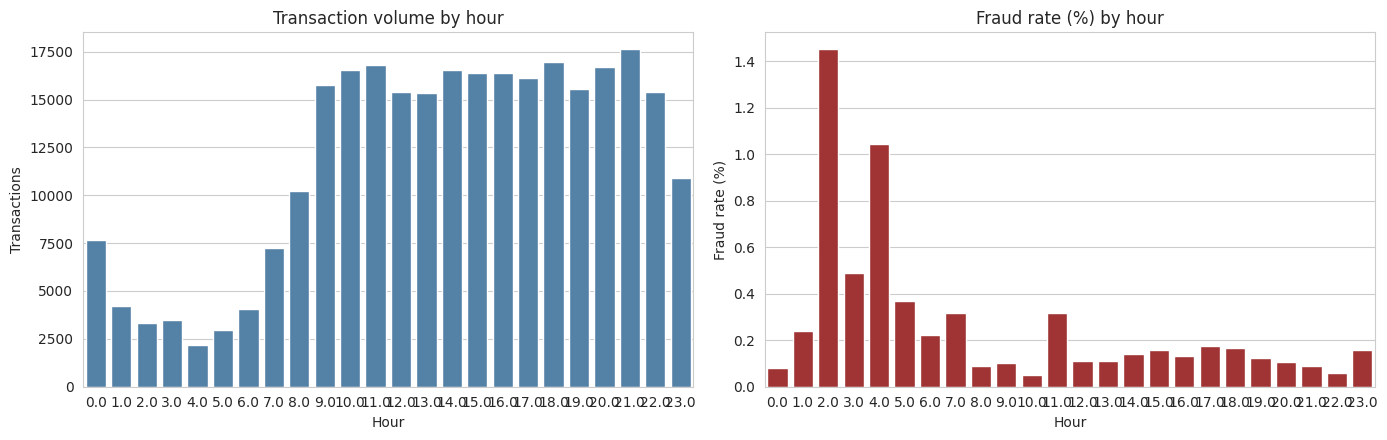

,fraud,total,fraud_rate_%
Hour,,,
2.0,48,3308,1.451
4.0,23,2204,1.044
3.0,17,3487,0.488
5.0,11,2988,0.368
7.0,23,7233,0.318


In [5]:
df['Hour'] = (df['Time'] // 3600) % 24
hourly = df.groupby('Hour')['Class'].agg(fraud='sum', total='count')
hourly['fraud_rate_%'] = hourly['fraud'] / hourly['total'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(x=hourly.index, y=hourly['total'], color='steelblue', ax=axes[0])
axes[0].set_title("Transaction volume by hour"); axes[0].set_ylabel("Transactions")
sns.barplot(x=hourly.index, y=hourly['fraud_rate_%'], color='firebrick', ax=axes[1])
axes[1].set_title("Fraud rate (%) by hour"); axes[1].set_ylabel("Fraud rate (%)")
plt.tight_layout()
plt.savefig("screenshots/03_hourly_analysis.png", dpi=100, bbox_inches='tight')
plt.show()
hourly.sort_values('fraud_rate_%', ascending=False).head(5).round(3)


**Observation:** Transaction volume drops sharply overnight (about 2,200 to 3,500 per hour in hours 2 to 5, versus roughly 16,000 per hour during the day), yet fraud does not drop with it, so the fraud *rate* spikes: **1.45% at hour 2** and **1.04% at hour 4**, about 9x and 6x the overall rate of 0.167%. Fraud hides in quiet hours when there is less legitimate traffic. Caution: the data covers only two days and the counts are small (48 frauds in the peak hour), so this is a pattern worth noting rather than a firm rule.

## 3. Why Accuracy Is Misleading Here

With ~0.17% fraud, a model that **never flags anything** is right about 99.8% of the time while catching zero fraud. We prove it below with a "dumb" baseline, after first preparing the data.

## 4. Preprocessing and Stratified Split

- `Time` is dropped (replaced by the engineered `Hour`).
- `Amount` is skewed with large outliers, so it is scaled with `RobustScaler` (uses median/IQR). The scaler is **fit on the training set only** to avoid leakage.
- The split is **stratified** so fraud cases appear in both train and test in the same proportion.

In [6]:
X = df.drop(columns=['Class', 'Time'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

scaler = RobustScaler().fit(X_train[['Amount']])
X_train = X_train.copy(); X_test = X_test.copy()
X_train['Amount'] = scaler.transform(X_train[['Amount']])
X_test['Amount'] = scaler.transform(X_test[['Amount']])

print("Train:", X_train.shape, "| fraud cases:", y_train.sum(), f"({y_train.mean()*100:.3f}%)")
print("Test: ", X_test.shape, "| fraud cases:", y_test.sum(), f"({y_test.mean()*100:.3f}%)")


Train: (226980, 30) | fraud cases: 378 (0.167%)
Test:  (56746, 30) | fraud cases: 95 (0.167%)


In [7]:
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
d_pred = dummy.predict(X_test)
print(f"'Never flag fraud' baseline -> accuracy: {accuracy_score(y_test, d_pred):.4f}, recall: {recall_score(y_test, d_pred):.4f}")


'Never flag fraud' baseline -> accuracy: 0.9983, recall: 0.0000


**Observation:** A model that never flags anything scores **99.83% accuracy and 0% recall**. Any real model must be judged on how well it finds the 95 test-set frauds, not on accuracy.

## 5. Handling Class Imbalance

Two techniques are used, and a plain model is kept as a control so their effect is visible:

1. **SMOTE (oversampling)** for Logistic Regression: creates synthetic fraud examples by interpolating between real fraud neighbours. It is applied **to the training set only**; the test set stays untouched and realistic.
2. **`class_weight='balanced_subsample'`** for Random Forest: instead of resampling, each tree penalises mistakes on the rare class more heavily. This is much cheaper than training a forest on hundreds of thousands of extra synthetic rows.

In [8]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_sm.value_counts().to_dict())


Before SMOTE: {0: 226602, 1: 378}
After SMOTE:  {0: 226602, 1: 226602}


## 6. Train the Models

In [9]:
# Control: Logistic Regression with no imbalance handling
lr_plain = LogisticRegression(max_iter=1000).fit(X_train, y_train)

# Logistic Regression trained on the SMOTE-balanced training set
lr_smote = LogisticRegression(max_iter=1000).fit(X_train_sm, y_train_sm)

# Random Forest with class weights (takes roughly 1-2 minutes)
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced_subsample',
                            n_jobs=-1, random_state=RANDOM_STATE).fit(X_train, y_train)
print("All models trained.")


All models trained.


## 7. Evaluation (Precision, Recall, F1, AUC-ROC)

In [10]:
models = {
    'LogReg (no handling)': lr_plain,
    'LogReg + SMOTE': lr_smote,
    'RandomForest (class weights)': rf,
}

rows = []
for name, m in models.items():
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rows.append({'Model': name,
                 'Accuracy': accuracy_score(y_test, pred),
                 'Precision': precision_score(y_test, pred),
                 'Recall': recall_score(y_test, pred),
                 'F1': f1_score(y_test, pred),
                 'AUC-ROC': roc_auc_score(y_test, proba),
                 'Avg Precision (PR-AUC)': average_precision_score(y_test, proba),
                 'Frauds caught': tp, 'Frauds missed': fn, 'False alarms': fp})
results = pd.DataFrame(rows).set_index('Model')
results.round(4)


,Accuracy,Precision,Recall,F1,AUC-ROC,Avg Precision (PR-AUC),Frauds caught,Frauds missed,False alarms
Model,,,,,,,,,
LogReg (no handling),0.9991,0.8438,0.5684,0.6792,0.9579,0.6895,54,41,10
LogReg + SMOTE,0.9738,0.0533,0.8737,0.1005,0.9613,0.6795,83,12,1474
RandomForest (class weights),0.9995,0.9853,0.7053,0.8221,0.9248,0.8129,67,28,1


**Observation:** Accuracy is above 97% for all three models and barely separates them, which confirms it is the wrong yardstick. The trade-offs are in the other columns:
- **Plain Logistic Regression** is precise (84%) but finds only 57% of frauds, because the rare class is outweighed during training.
- **Logistic Regression + SMOTE** pushes recall up to **87%** (83 of 95 frauds caught) but precision collapses to 5%: it raises **1,474 false alarms**, about 18 for every real fraud caught.
- **Random Forest with class weights** gives the best balance: **98.5% precision, 70.5% recall, F1 0.82**, with just 1 false alarm, though it misses 28 frauds.

In [11]:
# Detailed report for each model
for name, m in models.items():
    print("=" * 60); print(name); print("=" * 60)
    print(classification_report(y_test, m.predict(X_test), target_names=['Legitimate', 'Fraud'], digits=4))


LogReg (no handling)
              precision    recall  f1-score   support

  Legitimate     0.9993    0.9998    0.9995     56651
       Fraud     0.8438    0.5684    0.6792        95

    accuracy                         0.9991     56746
   macro avg     0.9215    0.7841    0.8394     56746
weighted avg     0.9990    0.9991    0.9990     56746

LogReg + SMOTE
              precision    recall  f1-score   support

  Legitimate     0.9998    0.9740    0.9867     56651
       Fraud     0.0533    0.8737    0.1005        95

    accuracy                         0.9738     56746
   macro avg     0.5265    0.9238    0.5436     56746
weighted avg     0.9982    0.9738    0.9852     56746

RandomForest (class weights)


              precision    recall  f1-score   support

  Legitimate     0.9995    1.0000    0.9997     56651
       Fraud     0.9853    0.7053    0.8221        95

    accuracy                         0.9995     56746
   macro avg     0.9924    0.8526    0.9109     56746
weighted avg     0.9995    0.9995    0.9994     56746



### 7.1 Confusion matrices

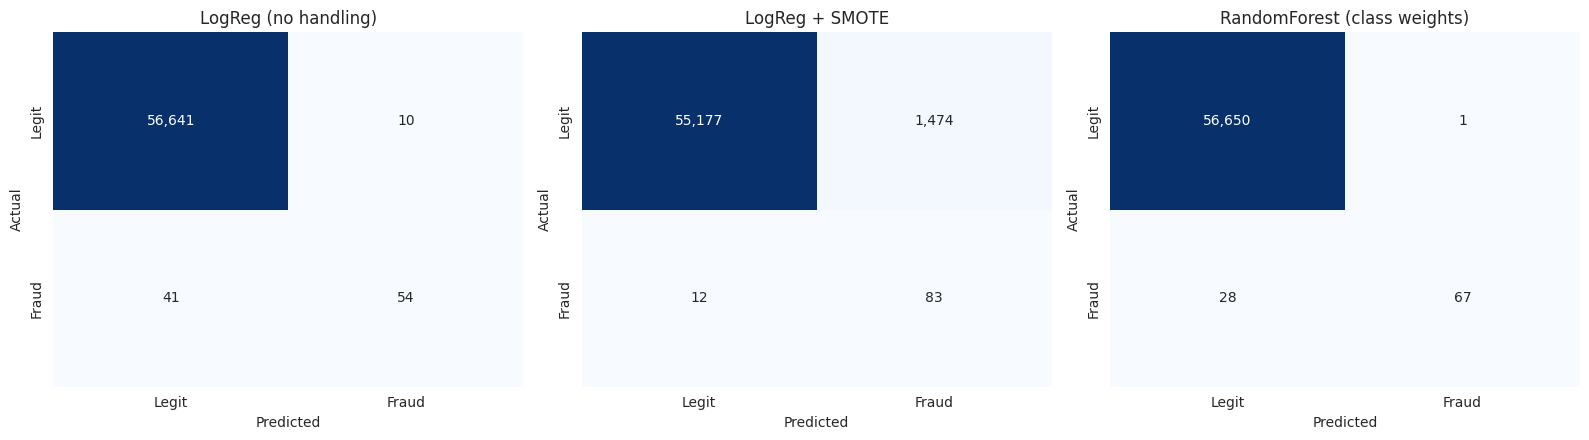

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, m) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, m.predict(X_test))
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("screenshots/04_confusion_matrices.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** The matrices make the trade-off visible. The Random Forest is nearly clean on legitimate transactions (1 false alarm) but lets 28 frauds through. LR + SMOTE catches the most fraud (83) but flags 1,474 legitimate transactions, which would mean a lot of blocked customers and manual reviews in practice.

### 7.2 ROC and Precision-Recall curves

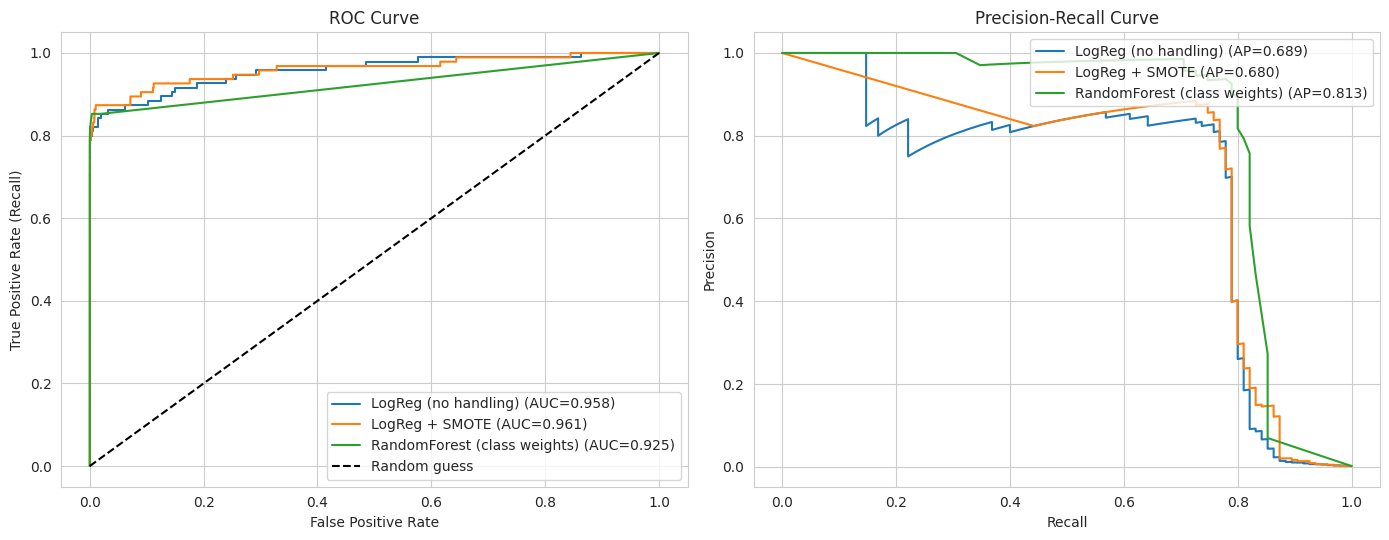

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for name, m in models.items():
    proba = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
    axes[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, proba):.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', label='Random guess')
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].set_title("ROC Curve"); axes[0].legend(loc='lower right')
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend(loc='upper right')
plt.tight_layout()
plt.savefig("screenshots/05_roc_pr_curves.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** The two curves tell different stories. By ROC-AUC the two Logistic Regression models (0.958 and 0.961) beat the Random Forest (0.925), but by average precision (area under the PR curve) the Random Forest is clearly best (0.813 vs 0.690 and 0.680). This is the ROC-vs-PR issue described above: ROC is flattered by the huge number of easy legitimate transactions, while the PR curve shows how well each model actually finds fraud without drowning in false alarms. A plausible reason for the Random Forest's lower ROC-AUC is that its scores are coarse and some frauds receive near-zero probability, though this was not tested separately. SMOTE did not improve the ranking quality of Logistic Regression (average precision 0.680 vs 0.690 without it); it mainly shifted the operating point toward higher recall at the cost of precision.

## 8. Which Metric Matters Most? Recall vs. Precision

In fraud detection the two kinds of error have very different costs:

- **A missed fraud (false negative)** means real money lost, and a customer who was actually harmed. This is what **recall** measures.
- **A false alarm (false positive)** means a blocked legitimate purchase, an annoyed customer, and analyst time spent reviewing. This is what **precision** measures.

Recall usually gets priority because a missed fraud costs far more than a declined card, but it cannot be maximised alone. A model can reach near-perfect recall by flagging almost everything, which is useless in practice. The right balance depends on the cost of a review versus the average cost of a fraud, and is controlled by the **decision threshold**, so the models are compared with **F1** and the **Precision-Recall curve** rather than accuracy.

**ROC-AUC vs. PR-AUC:** with so few positives, ROC-AUC can look flattering because the huge pool of legitimate transactions keeps the false-positive *rate* tiny even when thousands of false alarms occur. The PR curve (average precision) ignores true negatives, so it is the more honest summary for imbalanced data.

**Observation:** In this experiment the choice is concrete. If the priority is catching fraud at almost any cost, LR + SMOTE (87% recall) is the more sensitive option, but its 5% precision would swamp an analyst team. If the priority is trustworthy alerts, the Random Forest (98.5% precision) is far better but misses about 30% of frauds at the default 0.5 threshold. Since the thresholds here were not tuned, the best practical step is to lower the Random Forest's threshold to trade some precision for more recall, guided by the PR curve and the real cost of a review versus a fraud.

## 9. Feature Importance and Coefficients

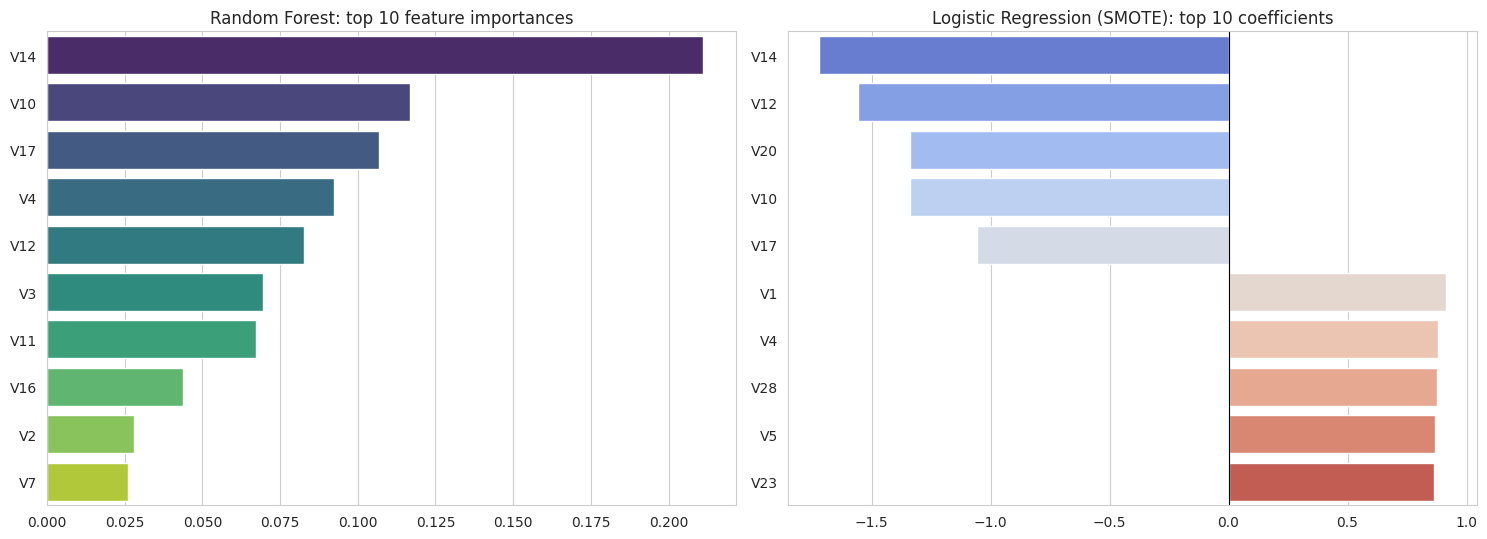

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
sns.barplot(x=imp.values, y=imp.index, hue=imp.index, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title("Random Forest: top 10 feature importances"); axes[0].set_ylabel('')

coef = pd.Series(lr_smote.coef_[0], index=X.columns)
top_coef = coef.reindex(coef.abs().sort_values(ascending=False).head(10).index)
sns.barplot(x=top_coef.values, y=top_coef.index, hue=top_coef.index, palette='coolwarm', legend=False, ax=axes[1])
axes[1].axvline(0, color='k', lw=0.8)
axes[1].set_title("Logistic Regression (SMOTE): top 10 coefficients"); axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig("screenshots/06_feature_importance.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** `V14` is the standout: it is the most important Random Forest feature (about 0.21, roughly double the next one) and the strongest negative Logistic Regression coefficient (about -1.7), meaning lower `V14` values push a transaction toward fraud. `V10`, `V12` and `V17` also rank highly in the forest and carry strong negative coefficients in the regression, so the two very different models agree on which features matter. The features are anonymised PCA components, so we can say *which* ones carry signal but not what they represent in real-world terms. The engineered `Hour` and the scaled `Amount` do not appear in either top 10.

## 10. Scalability: 1 Million Transactions per Hour

1 million transactions per hour is only about **278 transactions per second** on average. First, measure how quickly the trained models can score data on this machine:

In [15]:
for name, m in models.items():
    start = time.time()
    m.predict_proba(X_test)
    elapsed = time.time() - start
    print(f"{name:32s} scored {len(X_test):,} rows in {elapsed:.2f}s  ->  {len(X_test)/elapsed:,.0f} transactions/sec")
print("\nRequired average rate for 1M/hour: ~278 transactions/sec")


LogReg (no handling)             scored 56,746 rows in 0.01s  ->  7,525,531 transactions/sec
LogReg + SMOTE                   scored 56,746 rows in 0.00s  ->  11,486,968 transactions/sec


RandomForest (class weights)     scored 56,746 rows in 0.22s  ->  254,627 transactions/sec

Required average rate for 1M/hour: ~278 transactions/sec


**Observation:** In this run, Logistic Regression scored millions of transactions per second and the Random Forest hundreds of thousands per second (speeds vary a little from run to run), which is hundreds of times the ~278/sec needed for 1M per hour. Exact numbers depend on the machine and these figures are for batch scoring of ready-made features only, but they show that the model's raw speed is not the limiting factor.

**How the system would handle the load:**

1. **Separate training from scoring.** Training (including SMOTE and the forest fit) is slow, but it happens offline on a schedule. Only the lightweight `predict` step runs on live traffic.
2. **Throughput is not the real bottleneck; latency and peaks are.** Card authorisations must be decided in milliseconds, and traffic is bursty (the daily peak can be several times the average). The scoring service should be sized for peak load, run as stateless replicas behind a load balancer, and scored in micro-batches or one-by-one with a strict timeout and a safe fallback (for example a simple rule) if the model is slow.
3. **Feature computation dominates in production.** Here the features are ready-made. In reality, features such as "number of transactions on this card in the last hour" need a low-latency feature store or streaming aggregation (Kafka plus Spark/Flink), and that is usually harder to scale than the model itself.
4. **Choose model size deliberately.** Logistic Regression is tiny and extremely fast. The Random Forest is slower and larger in memory; if latency becomes a problem, reduce trees/depth or move to a gradient-boosted model, and consider a cheap first-stage model that sends only suspicious transactions to a heavier second-stage model.
5. **Keep the model fresh.** Fraud patterns shift as attackers adapt (concept drift), so monitor precision/recall on confirmed cases, retrain regularly, and retune the threshold. SMOTE is applied only when retraining and never to live data.
6. **Humans in the loop.** The threshold should also respect fraud-analyst capacity: flagging more transactions than the team can review has little value.

## 11. Conclusion

- **Imbalance:** Fraud is only 0.167% of transactions (473 of 283,726 after removing duplicates), so accuracy is meaningless: a model that flags nothing scores 99.83%.
- **EDA:** Fraud amounts are not simply larger (lower median, but a heavy tail), and the fraud *rate* spikes overnight (1.45% at hour 2) when legitimate traffic is lowest.
- **Models:** The Random Forest with class weights is the best overall (F1 0.82, average precision 0.81, 98.5% precision, only 1 false alarm), so it is the best candidate as the main model. Logistic Regression + SMOTE has the highest recall (87%) but 1,474 false alarms, which makes it better suited as a sensitive first-stage filter than as a final decision-maker.
- **Metrics:** ROC-AUC ranked the models differently from the PR curve; for imbalanced problems the PR-based view is more trustworthy.
- **Key signals:** `V14` (then `V10`, `V12`, `V17`) drives predictions in both model types.
- **Limitations and next steps:** The test set contains only 95 frauds, so each missed or caught case moves recall by about one point and the results are noisy. A single split and the default 0.5 threshold were used; cross-validation, threshold tuning, and gradient-boosted models (e.g. XGBoost) would be the natural next steps.

**Tech Stack:** Python, pandas, numpy, scikit-learn, imbalanced-learn (SMOTE), matplotlib, seaborn, Jupyter Notebook